# Cuvis Python SDK Example 2
## Load and analyse a recorded measurement

In this example an already recorded measurement (SessionFile .cu3s) is loaded.
The measurement's data and meta-data are accessed. 

**Used principles:**
 - *SessionFile* to load a recorded measurement
 - *Measurement* to access the SessionFiles data and meta-data

**Step-by-Step overview for this example:**
 1. Import and initialize Cuvis SDK
 2. Load the recorded measurement file using *SessionFile*
 3. Access meta-data about the recording *session*
 4. Extract a *Measurement* from the *SessionFile*
 5. Access data and meta-data from a single *Measurement*

**Prerequisites to running this example:**
 - Have a recorded measurement in *SessionFile* format (.cu3s) *or* downloaded the provided [demo data](https://cloud.cubert-gmbh.de/s/SDKSampleData)
 - Have the Cuvis SDK installed
 - Have Python and the requirements.txt installed

In [1]:
# If the import of cuvis fails, the most common cause is a mismatch between
# the _cuvis_ python package and the installed version of the Cuvis SDK.
# Try re-installing both and make sure that the version numbers match exactly
%matplotlib widget

import cuvis
import time
from matplotlib import pyplot as plt
print("Cuvis Python SDK Example 2")

# Initialize the Cuvis SDK using a settings-directory
# This is optional (all settings have defaults),
# but enables you to optimize Cuvis' performance on your system using the settings
# Your camera and the default Cuvis installation both provide these settings files
print("Initializing Cuvis")
cuvis.General.init("./settings")

Cuvis Python SDK Example 2
Initializing Cuvis


c:\Users\nima.ghorbani\code-repos\cuvis.python.examples\.venv\Lib\site-packages\cuvis\General.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#### SessionFile
A SessionFile is a Cubert-proprietary container file format for storing measurement data from Cubert cameras.
It simplifies dealing with the calibration files, reference measurement and actual measurements by merging everything into a single file.

**A SessionFile can contain:**
 - One or more *Measurements*
 - Reference Measurements (Dark, White, Distance, ...) (normally one per type)
 - Camera calibration file and Spectral Radiance calibration file
 - Meta-data about the recording settings (frame-rate, session name, etc.)

In [14]:
# Enter a path applicable to your setup here
import os
session_file_path = "./SDK_Training_Example_Data/WinterUlm_X20P.cu3s"
assert os.path.exists(session_file_path), f"Demo session file not found: {session_file_path}"

# Load the SessionFile
print(F"Loading Session File '{session_file_path}'")
session = cuvis.SessionFile(session_file_path)

Loading Session File './SDK_Training_Example_Data/WinterUlm_X20P.cu3s'


In [3]:
# Read and output some session file meta-data
print(F"Session File '{session_file_path}' meta-data:")

print(F"Number of measurements: {session.get_size()}")

print("Recorded with operation mode: ", end="")
recording_mode = session.operation_mode

if recording_mode == cuvis.OperationMode.Software:
    print("Software / Snapshot")
elif recording_mode == cuvis.OperationMode.Internal:
    print("Internal / Video")
else:
    print("External / Hardware Trigger")

if recording_mode == cuvis.OperationMode.Internal:
    print(F"Session recorded at a framerate of: {session.fps}")

print(F"Session File stores {session.get_size(cuvis.SessionItemType.references)} reference measurements")

Session File './SDK_Training_Example_Data/WinterUlm_X20P.cu3s' meta-data:
Number of measurements: 31
Recorded with operation mode: Software / Snapshot
Session File stores 4 reference measurements


#### Measurement
The *Measurement* class is the storage container for the actual hyperspectral data, along with more specific meta-data - things that can change from measurement to measurement (eg. integration time).

**A Measurement can contain:**
 - Multiple image data
 - A hyperspectral data cube
 - "Links" to reference measurements
 - Recording settings
 - Meta-data about the state of the camera
 - Meta-data about the software used to capture the measurement
 - Meta-data about the quality of the measurement

*Please note:* The hyperspectral cube is not always present. Processing the measurement to generate the hyperspectral cube is a compute-intensive step and is thus only done on-demand! By default, measurements are stored without the cube, but with all necessary data to generate it, to speed up saving and save on disk space (this shrinks measurements on average by about 50%)! 

In [4]:
# Fetch the first measurement from the session file
measurement = session.get_measurement(0)

In [5]:
# Read and print some meta-data from the measurement
print(F"Measurement meta-data for measurement {measurement.name}:")

print(F"Captured at: {measurement.capture_time}")
print(F"Captured with exposure / integration time of: {measurement.integration_time} ms")
print(F"Captured with camera: {measurement.product_name} - {measurement.serial_number}")
print(F"Captured with software version: {measurement.assembly}")
print(F"Captured to: {measurement.path}")

Measurement meta-data for measurement winter_ulm_000_0050:
Captured at: 2025-01-20 09:27:34.821000
Captured with exposure / integration time of: 7.0 ms
Captured with camera: Ultris X20P - BX20P221704
Captured with software version: 3.3.0 build: c9537bec41c2184bf68c9dcf05baea7aac3b9409 flags: RELEASE GPU_CUDA  platform: win32 architecture: 64 Bit
Captured to: SDK_Training_Example_Data\WinterUlm_X20P.cu3s


In [6]:
# Access some meta-data from the sensor of the camera at the time of recording.
# The raw sensor image of the hyperspectral sensor is called "IMAGE" by convention.
# Each sensors meta-data is the sensor name + "_info" suffix.
# You can iterate over the measurements data attribute to see all available data fields
sensor_data = measurement.data["IMAGE_info"]
print(F"Sensor pixel format: {sensor_data.pixel_format}")
print(F"Sensor readout timestamp: {sensor_data.readout_time}")
print(F"Sensor gain value: {sensor_data.gain}")
print(F"Raw sensor size (WxH): ({sensor_data.width}, {sensor_data.height}) pixel")
print(F"Sensor temperature: {sensor_data.temperature} °C")

Sensor pixel format: Mono12Packed
Sensor readout timestamp: 2025-01-20 09:27:34.821000
Sensor gain value: 1.1
Raw sensor size (WxH): (5120, 3840) pixel
Sensor temperature: 19.0 °C


In [7]:
# Access the hyperspectral cube

# If the cube is not generated, compute it now!
# By default, SessionFiles are saved without the cube to save disk space 
# -> The Processing Context is explained in detail in example 3 <-
if measurement.processing_mode == cuvis.ProcessingMode.Preview:
    pc = cuvis.ProcessingContext(session)
    pc.processing_mode = cuvis.ProcessingMode.Raw
    pc.apply(measurement)

cube = measurement.cube
#Or dummy random data for testing without cuvis package:
# class Cube:
#     def __init__(self, h, w, c):
#         self.height = h
#         self.width = w
#         self.channels = c
#         self.array = np.random.rand(h, w, c) * 100
#         self.wavelength = np.linspace(400, 700, c)
# cube = Cube(50, 50, 20)

In [8]:
# Access some fundamental information about the cube
print(F"Cube wavelength range: {cube.wavelength[0]}nm to {cube.wavelength[-1]}nm")
print(F"Cube spatial resolution (WxH): ({cube.width}, {cube.height}) pixel")
print(F"Cube spectral resolution: {cube.channels} channels @ ~{(cube.wavelength[-1] - cube.wavelength[0]) / cube.channels :.1f}nm per channel")

Cube wavelength range: 350nm to 1002nm
Cube spatial resolution (WxH): (410, 410) pixel
Cube spectral resolution: 164 channels @ ~4.0nm per channel


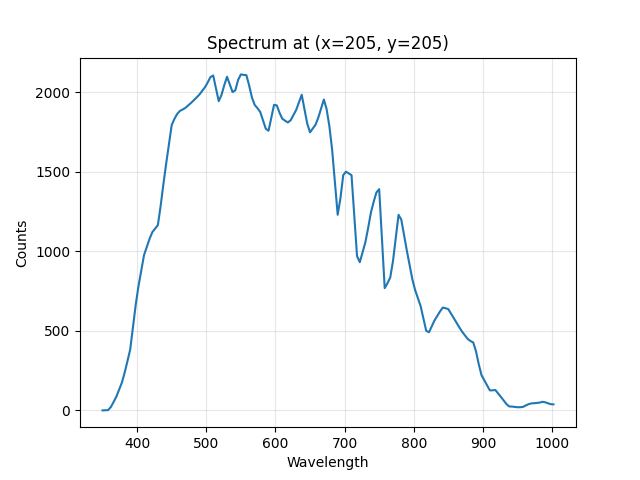

In [9]:
# Access a point spectrum (center pixel)
x = cube.width // 2
y = cube.height // 2
spectrum = cube.array[y,x,:]

plt.figure()
plt.plot(cube.wavelength, spectrum)
plt.xlabel("Wavelength")
plt.ylabel("Counts")
plt.title(f"Spectrum at (x={x}, y={y})")
plt.grid(True, alpha=0.3)
plt.show()

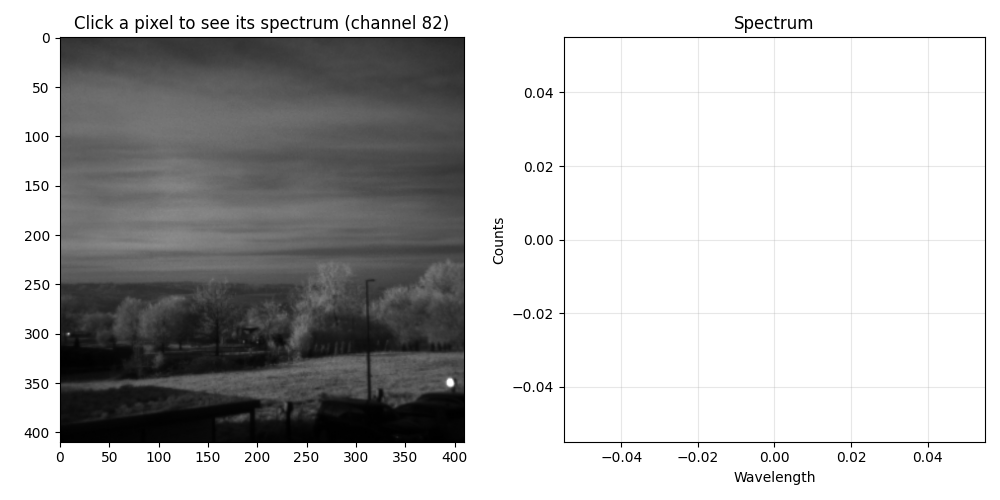

In [10]:
# Interactive pixel spectrum viewer

fig, (ax_img, ax_spec) = plt.subplots(1, 2, figsize=(10, 5))

# Start with middle channel image
mid_channel = cube.channels // 2
im = ax_img.imshow(cube.array[:, :, mid_channel], cmap='gray')
ax_img.set_title(f"Click a pixel to see its spectrum (channel {mid_channel})")

# Empty plot for spectrum
(line,) = ax_spec.plot([], [], lw=1.5)
ax_spec.set_xlabel("Wavelength")
ax_spec.set_ylabel("Counts")
ax_spec.set_title("Spectrum")
ax_spec.grid(True, alpha=0.3)

# Click event handler
def onclick(event):
    if event.inaxes == ax_img:
        x = int(event.xdata)
        y = int(event.ydata)
        spectrum = cube.array[y, x, :]
        line.set_data(cube.wavelength, spectrum)
        ax_spec.relim()
        ax_spec.autoscale_view()
        ax_spec.set_title(f"Spectrum at (x={x}, y={y})")
        fig.canvas.draw_idle()

# Connect click event
fig.canvas.mpl_connect('button_press_event', onclick)

plt.tight_layout()
plt.show()


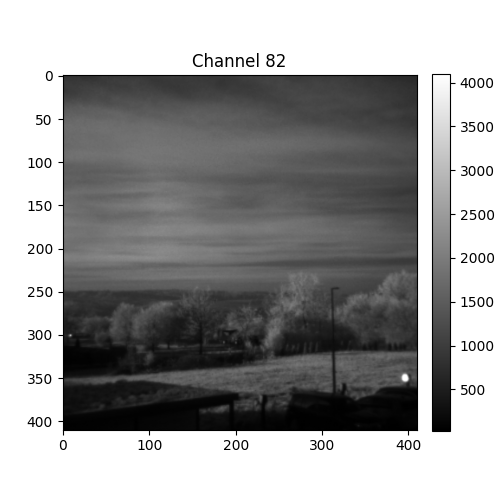

In [11]:
# Access a single channel (center channel)
c = cube.channels // 2
channel_image = cube.array[:,:,c]
fig = plt.figure(figsize=(5, 5))
fig.canvas.header_visible = False

im = plt.imshow(channel_image, cmap="gray")
plt.title(f"Channel {c}")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

In [12]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import numpy as np

def show_channel(c):
    channel_image = cube.array[:, :, c]
    fig = plt.figure(figsize=(5, 5))
    fig.canvas.header_visible = False

    im = plt.imshow(channel_image, cmap="gray")
    plt.title(f"Channel {c}")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.show()

# Create an interactive slider for channel index
interact(show_channel, c=widgets.IntSlider(min=0, max=cube.channels - 1, step=1, value=cube.channels // 2));


interactive(children=(IntSlider(value=82, description='c', max=163), Output()), _dom_classes=('widget-interact…

IntSlider(value=82, description='Channel', max=163)

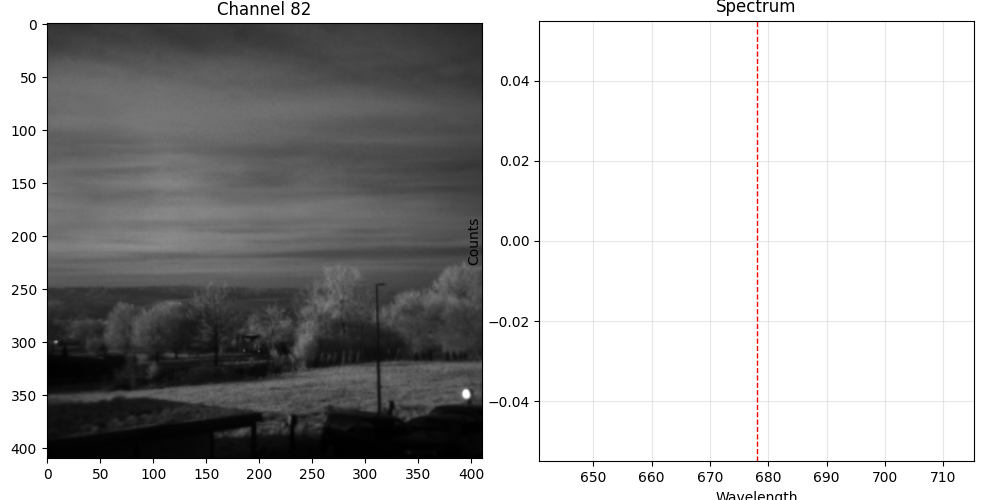

In [13]:
# The full interactive viewer with channel slider and pixel spectrum on click

fig, (ax_img, ax_spec) = plt.subplots(1, 2, figsize=(10, 5))

plt.tight_layout()

mid_channel = cube.channels // 2
im = ax_img.imshow(cube.array[:, :, mid_channel], cmap='gray')
marker, = ax_img.plot([], [], "r+", markersize=10, markeredgewidth=2)
ax_img.set_title(f"Channel {mid_channel}")

(line,) = ax_spec.plot([], [], lw=1.5)
vline = ax_spec.axvline(cube.wavelength[mid_channel], color="r", ls="--", lw=1)
ax_spec.set_xlabel("Wavelength")
ax_spec.set_ylabel("Counts")
ax_spec.set_title("Spectrum")
ax_spec.grid(True, alpha=0.3)

selected_pixel = {"x": None, "y": None}

# --- Channel slider setup (define before callbacks) ---
channel_slider = widgets.IntSlider(
    value=mid_channel,
    min=0,
    max=cube.channels - 1,
    step=1,
    description="Channel",
    continuous_update=True,
)

# --- Click handler ---
def onclick(event):
    if event.inaxes == ax_img and event.xdata is not None and event.ydata is not None:
        x, y = int(event.xdata), int(event.ydata)
        if 0 <= x < cube.array.shape[1] and 0 <= y < cube.array.shape[0]:
            selected_pixel["x"], selected_pixel["y"] = x, y
            marker.set_data([x], [y])
            
            spectrum = np.array(cube.array[y, x, :]).ravel()
            wavelengths = np.array(cube.wavelength).ravel()
            line.set_data(wavelengths, spectrum)

            ax_spec.relim()
            ax_spec.autoscale_view()
            ch = channel_slider.value
            vline.set_xdata([cube.wavelength[ch]])
            ax_spec.set_title(
                f"Spectrum at (x={x}, y={y}) — value={cube.array[y, x, ch]:.3f}"
            )
            fig.canvas.draw_idle()


fig.canvas.mpl_connect("button_press_event", onclick)

# --- Slider handler ---
def on_channel_change(change):
    if change["name"] == "value":
        ch = change["new"]
        im.set_data(cube.array[:, :, ch])
        ax_img.set_title(f"Channel {ch}")
        vline.set_xdata(cube.wavelength[ch])
        # keep marker visible even when no click yet
        if selected_pixel["x"] is not None:
            x, y = selected_pixel["x"], selected_pixel["y"]
            marker.set_data([x], [y]) 
            ax_spec.set_title(
                f"Spectrum at (x={x}, y={y}) — value={cube.array[y, x, ch]:.3f}"
            )
        else:
            marker.set_data([], []) 
        fig.canvas.draw_idle()

channel_slider.observe(on_channel_change, names="value")

display(channel_slider)
plt.show()
